Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.metrics import mean_squared_error

Loading Data

In [2]:
df = pd.read_csv(r'C:/Users/JOVAN RODRIGUES/Desktop/NCI Study/Statistics/Fishmarket.csv')
print(df)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)
print(df['Species'].unique())

    Species  Weight  Length1  Length2  Length3   Height   Width
0     Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1     Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2     Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
3     Bream   363.0     26.3     29.0     33.5  12.7300  4.4555
4     Bream   430.0     26.5     29.0     34.0  12.4440  5.1340
..      ...     ...      ...      ...      ...      ...     ...
153   Smelt    12.2     11.5     12.2     13.4   2.0904  1.3936
154   Smelt    13.4     11.7     12.4     13.5   2.4300  1.2690
155   Smelt    12.2     12.1     13.0     13.8   2.2770  1.2558
156   Smelt    19.7     13.2     14.3     15.2   2.8728  2.0672
157   Smelt    19.9     13.8     15.0     16.2   2.9322  1.8792

[158 rows x 7 columns]
Dataset shape: (158, 7)

Column names: ['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']

Data types:
Species        str
Weight     float64
Length1    float64
Length2    float64
Length

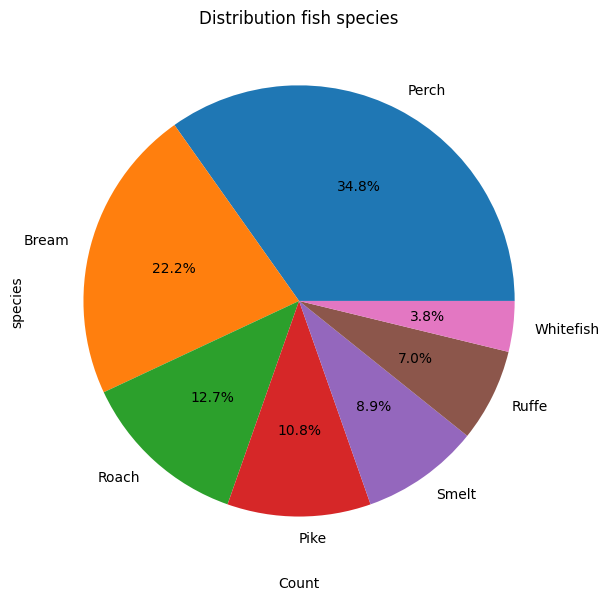

In [3]:
f_types= df['Species'].value_counts(normalize=True) * 100
f_types.plot(kind="pie", fontsize=10,autopct='%1.1f%%',figsize=(7,7))
plt.title("Distribution fish species")
plt.xlabel("Count")
plt.ylabel("species")
plt.show()

Exploratory Data Analysis 

In [4]:
#Searching for Eronomous weights 
numeric_cols = ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']
for col in numeric_cols:
    min_vals = (df[col]).min()
    print(f"minimum {col}: {min_vals}")

minimum Weight: 0.0
minimum Length1: 7.5
minimum Length2: 8.4
minimum Length3: 8.8
minimum Height: 1.7284
minimum Width: 1.0476


In [5]:
#Cleaning the Eronomous Data 
df_cleaned = df[df['Weight'] > 0].copy()
print("Rows after removing erroneous data:", len(df_cleaned))
new_min_weight= df_cleaned['Weight'].min()
print('New Min Weight : ', new_min_weight)

Rows after removing erroneous data: 157
New Min Weight :  5.9


           Weight   Length1   Length2   Length3    Height     Width
Weight   1.000000  0.915782  0.918759  0.923968  0.723454  0.885319
Length1  0.915782  1.000000  0.999511  0.991979  0.621970  0.865186
Length2  0.918759  0.999511  1.000000  0.994071  0.637186  0.871799
Length3  0.923968  0.991979  0.994071  1.000000  0.700855  0.877142
Height   0.723454  0.621970  0.637186  0.700855  1.000000  0.791484
Width    0.885319  0.865186  0.871799  0.877142  0.791484  1.000000


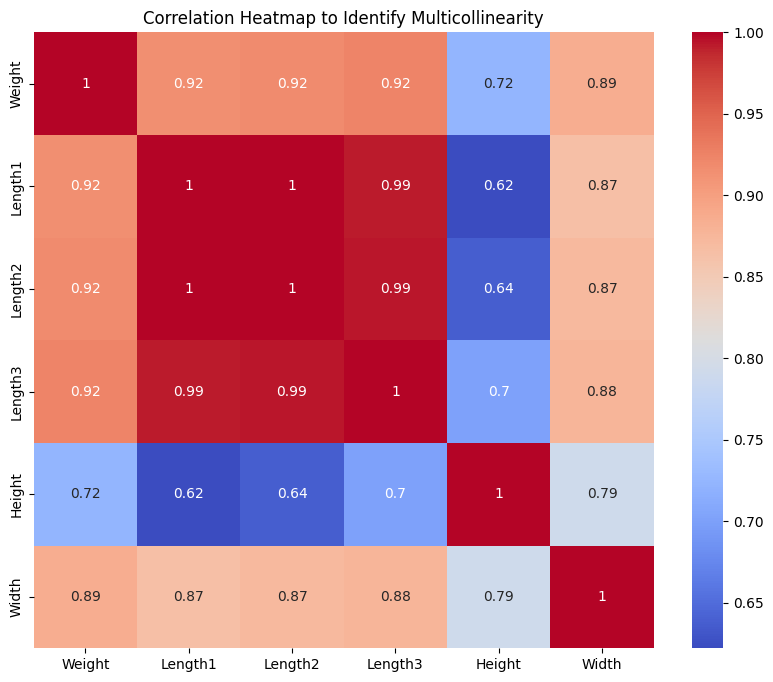

In [6]:
# Check correlation between dimensions 
correlation_matrix = df_cleaned[['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']].corr()
print(correlation_matrix)

# Visualization of correlation 
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap to Identify Multicollinearity")
plt.show()


In [7]:
vif_data = df_cleaned[['Length1', 'Length2', 'Length3', 'Height', 'Width']].copy()
vif_data = sm.add_constant(vif_data)

vif_results = pd.DataFrame()
vif_results['Variable'] = vif_data.columns
vif_results['VIF'] = [variance_inflation_factor(vif_data.values, i)
                      for i in range(vif_data.shape[1])]
vif_results = vif_results[vif_results['Variable'] != 'const']
print('VIF WITH all three length variables:')
print(vif_results.round(2))
print('\nLength1/Length2/Length3 have extremely high VIF — confirms severe multicollinearity.')

VIF WITH all three length variables:
  Variable      VIF
1  Length1  1663.50
2  Length2  2062.21
3  Length3   426.34
4   Height    14.67
5    Width    12.12

Length1/Length2/Length3 have extremely high VIF — confirms severe multicollinearity.


In [8]:

# Based on high correlation drop Length1 and Length2 
#  Length3 (Total Length) is used for the final prediction 
df_refined = df_cleaned.drop(columns=['Length1', 'Length2'])
print(df_refined)

    Species  Weight  Length3   Height   Width
0     Bream   242.0     30.0  11.5200  4.0200
1     Bream   290.0     31.2  12.4800  4.3056
2     Bream   340.0     31.1  12.3778  4.6961
3     Bream   363.0     33.5  12.7300  4.4555
4     Bream   430.0     34.0  12.4440  5.1340
..      ...     ...      ...      ...     ...
153   Smelt    12.2     13.4   2.0904  1.3936
154   Smelt    13.4     13.5   2.4300  1.2690
155   Smelt    12.2     13.8   2.2770  1.2558
156   Smelt    19.7     15.2   2.8728  2.0672
157   Smelt    19.9     16.2   2.9322  1.8792

[157 rows x 5 columns]


            Weight     Length1     Length2     Length3      Height       Width
count   157.000000  157.000000  157.000000  157.000000  157.000000  157.000000
mean    396.394268   26.212102   28.379618   31.195541    8.962501    4.408664
std     354.421370    9.991473   10.711028   11.615652    4.298036    1.683004
min       5.900000    7.500000    8.400000    8.800000    1.728400    1.047600
25%     120.000000   19.100000   21.000000   23.200000    5.936400    3.395700
50%     273.000000   25.200000   27.300000   29.400000    7.786000    4.248500
75%     650.000000   32.700000   35.000000   39.600000   12.354000    5.580000
max    1650.000000   59.000000   63.400000   68.000000   18.957000    8.142000


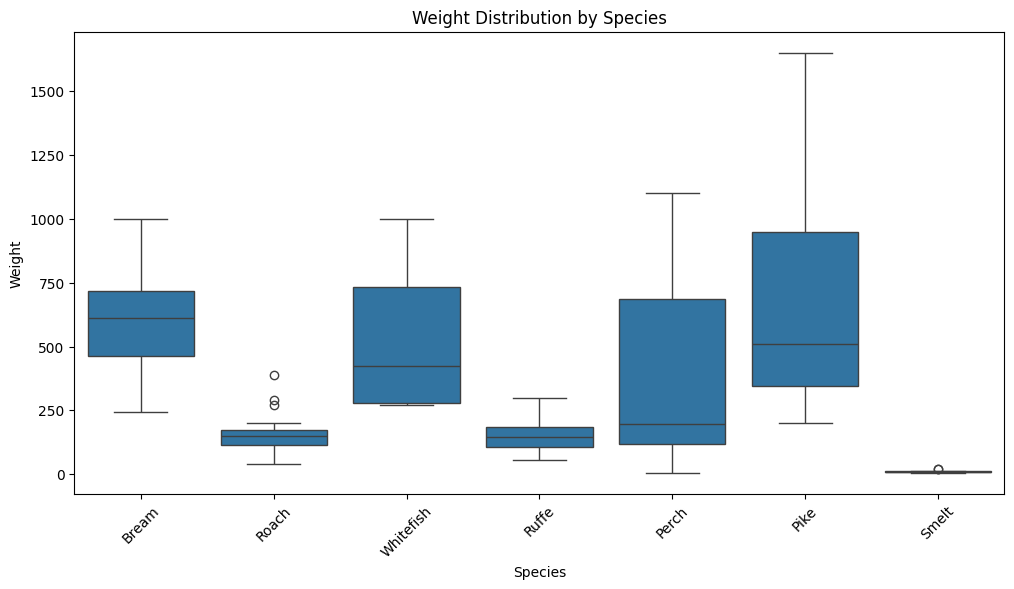

In [9]:
# Descriptive statistics for the report 
print(df_cleaned.describe())

# Visualization: Boxplot of Weight by Species 
plt.figure(figsize=(12, 6))
sns.boxplot(x='Species', y='Weight', data=df_cleaned)
plt.title("Weight Distribution by Species")
plt.xticks(rotation=45)
plt.show()

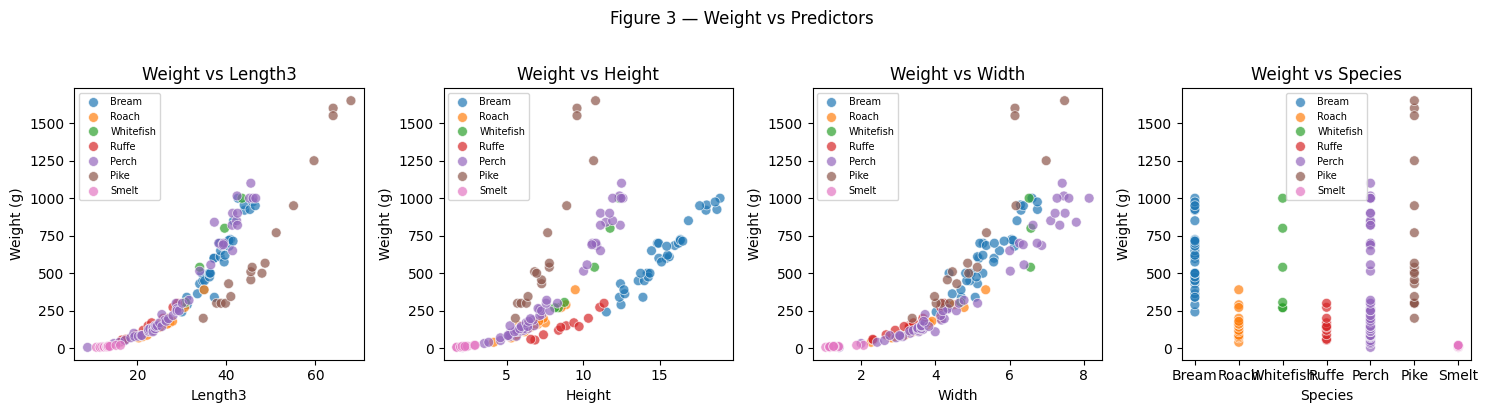

In [10]:
predictors = ['Length3', 'Height', 'Width','Species']
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for i, col in enumerate(predictors):
    sns.scatterplot(data=df_cleaned, x=col, y='Weight',
                    hue='Species', ax=axes[i], alpha=0.7, s=50)
    axes[i].set_title(f'Weight vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Weight (g)')
    axes[i].legend(fontsize=7)

plt.suptitle('Figure 3 — Weight vs Predictors ', y=1.02)
plt.tight_layout()
plt.savefig('fig3_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
#note the curved, non-linear pattern. Log looks more appropriate due to curve as mentinoed in class

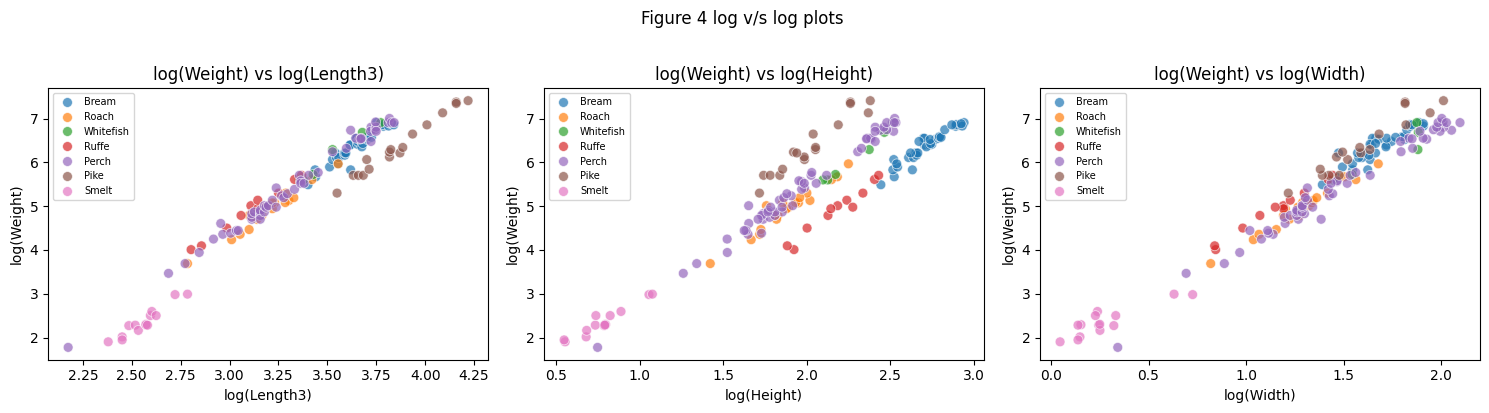

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
predictors = ['Length3', 'Height', 'Width']
for i, col in enumerate(predictors):
    sns.scatterplot(data=df_cleaned, x=np.log(df_cleaned[col]),
                    y=np.log(df_cleaned['Weight']),
                    hue=df_cleaned['Species'], ax=axes[i], alpha=0.7, s=50)
    axes[i].set_title(f'log(Weight) vs log({col})')
    axes[i].set_xlabel(f'log({col})')
    axes[i].set_ylabel('log(Weight)')
    axes[i].legend(fontsize=7)

plt.suptitle('Figure 4 log v/s log plots ', y=1.02)
plt.tight_layout()
plt.savefig('fig4_loglog_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
df_encoded = pd.get_dummies(df_refined, columns=['Species'], drop_first=True)
print(df_encoded.dtypes)
df_encoded = df_encoded.astype(float)
print(df_encoded.head())

Weight               float64
Length3              float64
Height               float64
Width                float64
Species_Perch           bool
Species_Pike            bool
Species_Roach           bool
Species_Ruffe           bool
Species_Smelt           bool
Species_Whitefish       bool
dtype: object
   Weight  Length3   Height   Width  Species_Perch  Species_Pike  \
0   242.0     30.0  11.5200  4.0200            0.0           0.0   
1   290.0     31.2  12.4800  4.3056            0.0           0.0   
2   340.0     31.1  12.3778  4.6961            0.0           0.0   
3   363.0     33.5  12.7300  4.4555            0.0           0.0   
4   430.0     34.0  12.4440  5.1340            0.0           0.0   

   Species_Roach  Species_Ruffe  Species_Smelt  Species_Whitefish  
0            0.0            0.0            0.0                0.0  
1            0.0            0.0            0.0                0.0  
2            0.0            0.0            0.0                0.0  
3            0.

In [13]:
print(df_encoded.columns.unique())

Index(['Weight', 'Length3', 'Height', 'Width', 'Species_Perch', 'Species_Pike',
       'Species_Roach', 'Species_Ruffe', 'Species_Smelt', 'Species_Whitefish'],
      dtype='str')


#Regression Model


#Model Linear Regression

In [14]:
X = df_encoded.drop('Weight', axis=1)
y = df_encoded['Weight']

import statsmodels.api as sm
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     227.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.18e-81
Time:                        00:53:43   Log-Likelihood:                -931.62
No. Observations:                 157   AIC:                             1883.
Df Residuals:                     147   BIC:                             1914.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -851.8702     85.05

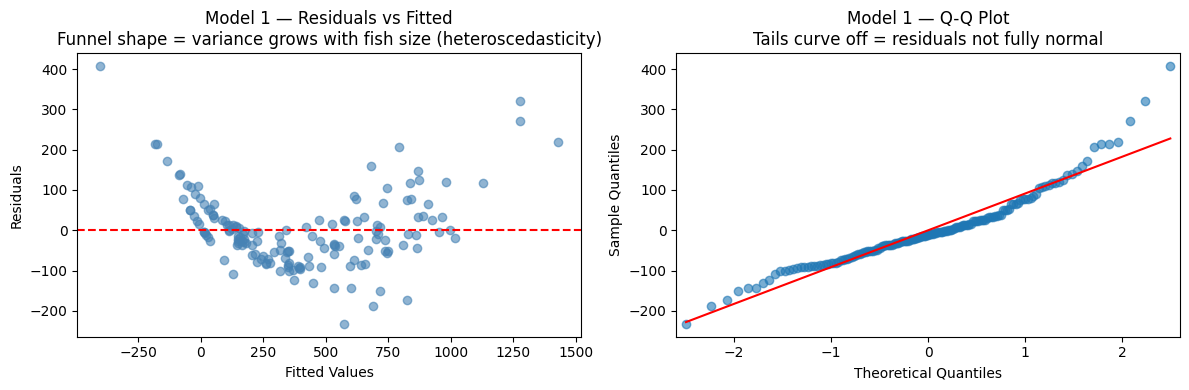

In [15]:
# Q-Q plot for Model 1 — checks if residuals are normally distributed
# Points should follow the diagonal line
# Heavy tails curving off = not normal which is expected for linear model
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(model.fittedvalues, model.resid, color='steelblue', alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Model 1 — Residuals vs Fitted\n'
                  'Funnel shape = variance grows with fish size (heteroscedasticity)')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

sm.qqplot(model.resid, line='s', ax=axes[1], alpha=0.6)
axes[1].set_title('Model 1 — Q-Q Plot\n'
                  'Tails curve off = residuals not fully normal')

plt.tight_layout()
plt.show()

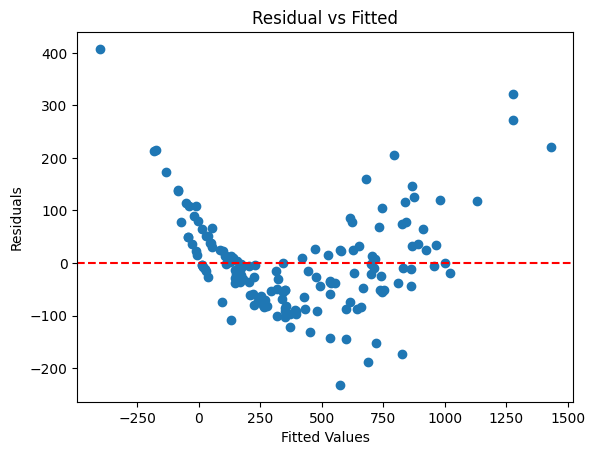

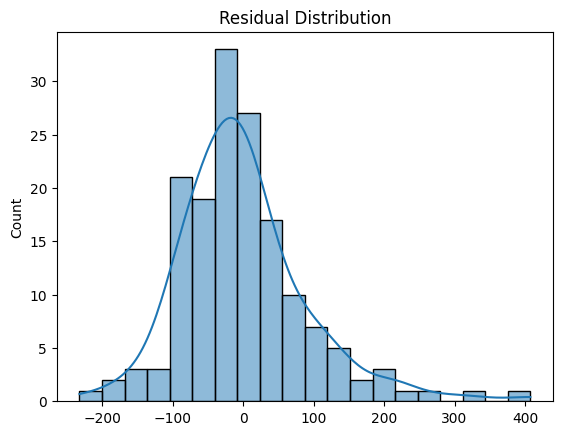

In [16]:
residuals = model.resid

# Residual plot
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted")
plt.show()

# Histogram of residuals
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

Model 1 — Outliers found: 13
       Species  Weight  Length3
13       Bream   340.0     37.3
29       Bream  1000.0     42.6
35       Roach    40.0     16.2
60   Whitefish  1000.0     43.5
61       Ruffe    55.0     16.5
72       Perch     5.9      8.8
73       Perch    32.0     14.7
111      Perch   840.0     37.3
117      Perch   650.0     41.4
136       Pike   500.0     48.0
141       Pike  1600.0     64.0
142       Pike  1550.0     64.0
143       Pike  1650.0     68.0


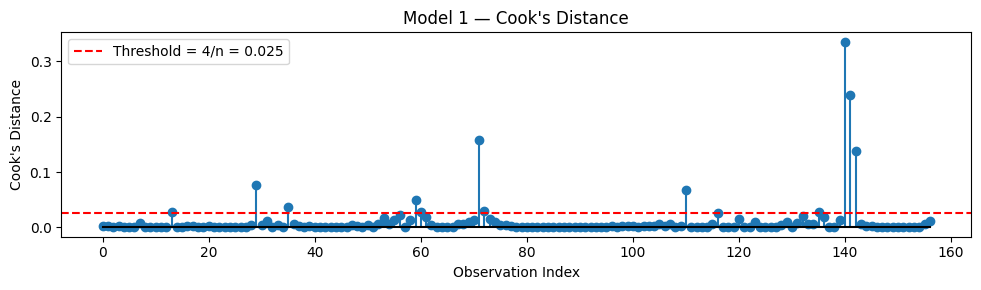

In [17]:
# Finds observations that influence the model too much
cooks1, _  = model.get_influence().cooks_distance
threshold1 = 4 / len(df_encoded)
outliers1  = np.where(cooks1 > threshold1)[0]

print(f"Model 1 — Outliers found: {len(outliers1)}")
print(df_refined.iloc[outliers1][['Species', 'Weight', 'Length3']])

plt.figure(figsize=(10, 3))
plt.stem(range(len(cooks1)), cooks1,
         markerfmt='C0o', linefmt='C0-', basefmt='k-')
plt.axhline(threshold1, color='red', linestyle='--',
            label=f'Threshold = 4/n = {threshold1:.3f}')
plt.title("Model 1 — Cook's Distance")
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Predictions
y_pred = model.predict(X)
# RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("RMSE:", rmse)

RMSE: 91.37103500744897


In [19]:
X_final = df_encoded.drop('Weight', axis=1)
y_final = df_encoded['Weight']

import statsmodels.api as sm
X_final = sm.add_constant(X_final)

final_model = sm.OLS(y_final, X_final).fit()



In [20]:
new_fish = pd.DataFrame({
    'const': [1],
    'Length3': [41.9],
    'Height': [12.8],
    'Width': [6.9],
    'Species_Perch':     [1],   
    'Species_Pike':      [0],      
    'Species_Roach':     [0],      
    'Species_Ruffe':     [0],      
    'Species_Smelt':     [0],     
    'Species_Whitefish': [0]
})

# Prediction
predicted_weight = final_model.predict(new_fish)

print("Predicted Weight (grams):", predicted_weight[0])

Predicted Weight (grams): 852.5738982800099


In [21]:
#linear with Interactions 

In [22]:
df_interact = df_encoded[['Weight','Length3','Height','Width',
                           'Species_Perch','Species_Pike','Species_Roach',
                           'Species_Ruffe','Species_Smelt','Species_Whitefish']].copy()

# Step 2: Add ONLY Length3 × Species interactions
species_cols = ['Species_Perch','Species_Pike','Species_Roach',
                'Species_Ruffe','Species_Smelt','Species_Whitefish']

for sp in species_cols:
    df_interact[f'L3x{sp}'] = df_interact['Length3'] * df_interact[sp]

print("Columns in interaction model:")
print(df_interact.columns.tolist())


X2 = sm.add_constant(df_interact.drop('Weight', axis=1))
y2 = df_interact['Weight']

model2 = sm.OLS(y2, X2).fit()
print(model2.summary())


Columns in interaction model:
['Weight', 'Length3', 'Height', 'Width', 'Species_Perch', 'Species_Pike', 'Species_Roach', 'Species_Ruffe', 'Species_Smelt', 'Species_Whitefish', 'L3xSpecies_Perch', 'L3xSpecies_Pike', 'L3xSpecies_Roach', 'L3xSpecies_Ruffe', 'L3xSpecies_Smelt', 'L3xSpecies_Whitefish']
                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     275.6
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           2.17e-96
Time:                        00:53:52   Log-Likelihood:                -876.13
No. Observations:                 157   AIC:                             1784.
Df Residuals:                     141   BIC:                             1833.
Df Model:                          15                                

In [23]:
print("P-values — remove anything above 0.05:\n")
for var, pval in model2.pvalues.items():
    if var == 'const': continue
    status = 'keep' if pval <= 0.05 else 'remove'
    print(f"  {var:<35} p={pval:.4f}  {status}")

# Refit with only significant variables
sig2     = [v for v, p in model2.pvalues.items() if p <= 0.05 and v != 'const']
model2_f = sm.OLS(y2, sm.add_constant(df_interact[sig2])).fit()

print(f"R² = {model2_f.rsquared:.4f}   Adj R² = {model2_f.rsquared_adj:.4f}")
    

P-values — remove anything above 0.05:

  Length3                             p=0.0021  keep
  Height                              p=0.0017  keep
  Width                               p=0.0091  keep
  Species_Perch                       p=0.0000  keep
  Species_Pike                        p=0.0002  keep
  Species_Roach                       p=0.0000  keep
  Species_Ruffe                       p=0.0000  keep
  Species_Smelt                       p=0.0000  keep
  Species_Whitefish                   p=0.5472  remove
  L3xSpecies_Perch                    p=0.0507  remove
  L3xSpecies_Pike                     p=0.0013  keep
  L3xSpecies_Roach                    p=0.0001  keep
  L3xSpecies_Ruffe                    p=0.0000  keep
  L3xSpecies_Smelt                    p=0.0117  keep
  L3xSpecies_Whitefish                p=0.1086  remove
R² = 0.9584   Adj R² = 0.9549


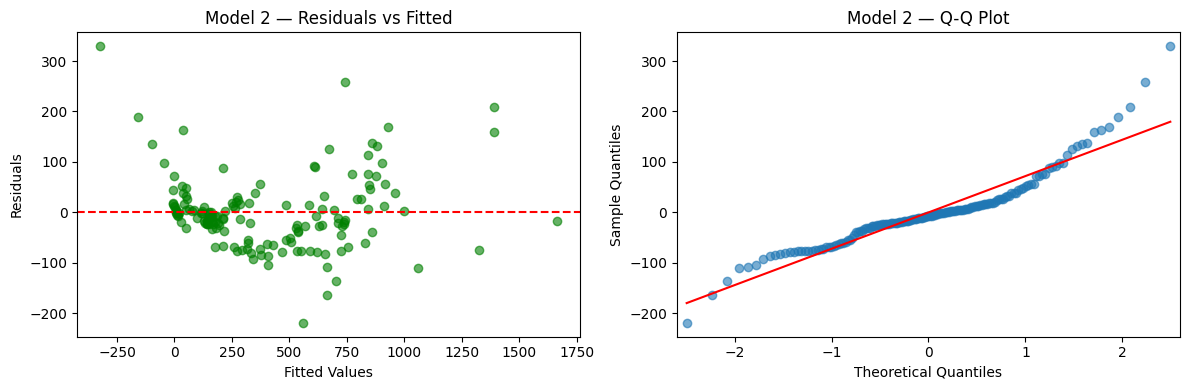

Outliers found: 10
       Species  Weight  Length3
29       Bream  1000.0     42.6
59   Whitefish   800.0     39.6
60   Whitefish  1000.0     43.5
72       Perch     5.9      8.8
73       Perch    32.0     14.7
124      Perch  1100.0     45.5
127       Pike   200.0     34.8
136       Pike   500.0     48.0
141       Pike  1600.0     64.0
142       Pike  1550.0     64.0


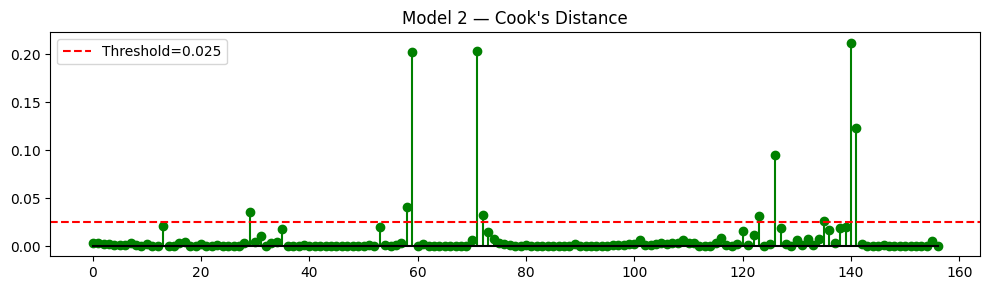

In [24]:
#Diagnostic plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(model2_f.fittedvalues, model2_f.resid, color='green', alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Model 2 — Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

sm.qqplot(model2_f.resid, line='s', ax=axes[1], alpha=0.6)
axes[1].set_title('Model 2 — Q-Q Plot')

plt.tight_layout()
plt.show()


#Find influential outliers
cooks2, _  = model2_f.get_influence().cooks_distance
threshold  = 4 / len(df_interact)
outliers2  = np.where(cooks2 > threshold)[0]

print(f"Outliers found: {len(outliers2)}")
print(df_refined.iloc[outliers2][['Species','Weight','Length3']])

plt.figure(figsize=(10, 3))
plt.stem(range(len(cooks2)), cooks2, markerfmt='go', linefmt='g-', basefmt='k-')
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold={threshold:.3f}')
plt.title("Model 2 — Cook's Distance")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# RMSE for Model 2
rmse_model2 = np.sqrt(mean_squared_error(y2, model2_f.predict(sm.add_constant(df_interact[sig2]))))
print(f"Model 2 RMSE: {rmse_model2:.2f} grams")

# Predict Perch weight using Model
L3 = 41.9
perch2 = {
    'Length3':              L3,
    'Height':               12.8,
    'Width':                6.9,
    'Species_Perch':        1,   'Species_Pike':       0,
    'Species_Roach':        0,   'Species_Ruffe':      0,
    'Species_Smelt':        0,   'Species_Whitefish':  0,
    'L3xSpecies_Perch':     L3,  # 41.9 × 1
    'L3xSpecies_Pike':      0,   'L3xSpecies_Roach':   0,
    'L3xSpecies_Ruffe':     0,   'L3xSpecies_Smelt':   0,
    'L3xSpecies_Whitefish': 0,
}
# Keep only columns the refined model used
m2_vars   = [v for v in model2_f.model.exog_names if v != 'const']
perch_X2  = sm.add_constant(pd.DataFrame([perch2])[m2_vars], has_constant='add')
perch_X2  = perch_X2[model2_f.model.exog_names]

print(f"Model 2 Perch prediction: {model2_f.predict(perch_X2)[0]:.2f} grams")

Model 2 RMSE: 72.06 grams
Model 2 Perch prediction: 838.24 grams


In [26]:
#Log 

In [27]:
#Data Columns 
df_log = df_encoded[['Weight','Length3','Height','Width',
                      'Species_Perch','Species_Pike','Species_Roach',
                      'Species_Ruffe','Species_Smelt','Species_Whitefish']].copy()

# Log-transform Weight and the 3 numeric predictors
# Species dummies stay as 0/1 — you cannot log a binary column
df_log['log_Weight']  = np.log(df_log['Weight'])
df_log['log_Length3'] = np.log(df_log['Length3'])
df_log['log_Height']  = np.log(df_log['Height'])
df_log['log_Width']   = np.log(df_log['Width'])

print(df_log[['Weight','log_Weight','Length3','log_Length3']].head(4).round(3))

# y is log_Weight, NOT Weight
X3 = sm.add_constant(df_log[['log_Length3','log_Height','log_Width',
                               'Species_Perch','Species_Pike','Species_Roach',
                               'Species_Ruffe','Species_Smelt','Species_Whitefish']])
y3 = df_log['log_Weight']

model3 = sm.OLS(y3, X3).fit()
print(model3.summary())

   Weight  log_Weight  Length3  log_Length3
0   242.0       5.489     30.0        3.401
1   290.0       5.670     31.2        3.440
2   340.0       5.829     31.1        3.437
3   363.0       5.894     33.5        3.512
                            OLS Regression Results                            
Dep. Variable:             log_Weight   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     3900.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          3.86e-170
Time:                        00:53:56   Log-Likelihood:                 163.80
No. Observations:                 157   AIC:                            -307.6
Df Residuals:                     147   BIC:                            -277.0
Df Model:                           9                                         
Covariance Type:            nonrobust                                

In [28]:
# Check p-values
print("P-values:\n")
for var, pval in model3.pvalues.items():
    if var == 'const': continue
    status = 'keep' if pval <= 0.05 else 'remove'
    print(f"  {var:<30} p={pval:.4f}  {status}")

# Refit with only significant variables
sig3     = [v for v, p in model3.pvalues.items() if p <= 0.05 and v != 'const']
model3_f = sm.OLS(y3, sm.add_constant(df_log[sig3])).fit()

print(f"R² = {model3_f.rsquared:.4f}   Adj R² = {model3_f.rsquared_adj:.4f}")    

P-values:

  log_Length3                    p=0.0000  keep
  log_Height                     p=0.0000  keep
  log_Width                      p=0.0000  keep
  Species_Perch                  p=0.0006  keep
  Species_Pike                   p=0.3629  remove
  Species_Roach                  p=0.0278  keep
  Species_Ruffe                  p=0.0000  keep
  Species_Smelt                  p=0.8721  remove
  Species_Whitefish              p=0.0001  keep
R² = 0.9957   Adj R² = 0.9955


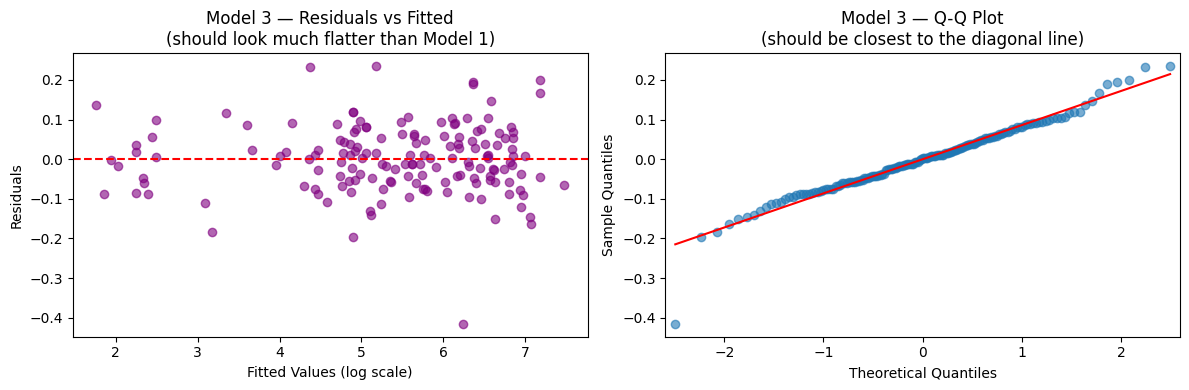

Outliers found: 11


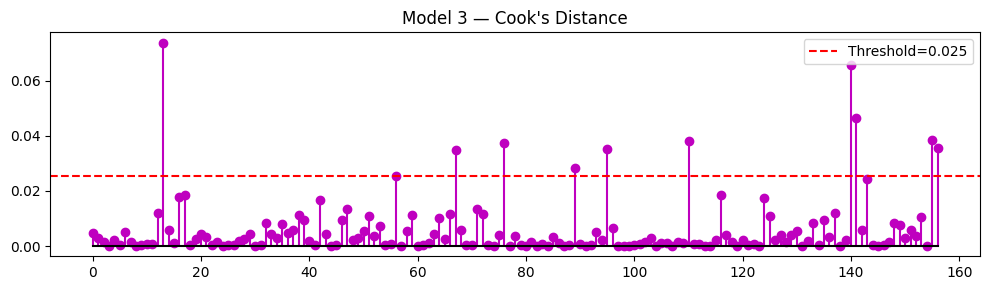

In [29]:
# Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(model3_f.fittedvalues, model3_f.resid, color='purple', alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Model 3 — Residuals vs Fitted\n(should look much flatter than Model 1)')
axes[0].set_xlabel('Fitted Values (log scale)')
axes[0].set_ylabel('Residuals')

sm.qqplot(model3_f.resid, line='s', ax=axes[1], alpha=0.6)
axes[1].set_title('Model 3 — Q-Q Plot\n(should be closest to the diagonal line)')

plt.tight_layout()
plt.show()

# Cook's Distance
cooks3, _  = model3_f.get_influence().cooks_distance
threshold3 = 4 / len(df_log)
outliers3  = np.where(cooks3 > threshold3)[0]
print(f"Outliers found: {len(outliers3)}")
plt.figure(figsize=(10, 3))
plt.stem(range(len(cooks3)), cooks3, markerfmt='mo', linefmt='m-', basefmt='k-')
plt.axhline(threshold3, color='red', linestyle='--', label=f'Threshold={threshold3:.3f}')
plt.title("Model 3 — Cook's Distance")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
#  RMSE for Model 3
# model predicted log(Weight) np.exp() to get grams back
log_preds   = model3_f.predict(sm.add_constant(df_log[sig3]))
gram_preds  = np.exp(log_preds)          # ← THIS step is what was missing before

rmse_model3 = np.sqrt(mean_squared_error(df_log['Weight'], gram_preds))
print(f"Model 3 RMSE: {rmse_model3:.2f} grams")

#Predict Perch weight using Model 3
# Log-transform the inputs first — same as training
perch3 = {
    'log_Length3':        np.log(41.9),
    'log_Height':         np.log(12.8),
    'log_Width':          np.log(6.9),
    'Species_Perch':      1,   'Species_Pike':      0,
    'Species_Roach':      0,   'Species_Ruffe':     0,
    'Species_Smelt':      0,   'Species_Whitefish': 0,
}
m3_vars  = [v for v in model3_f.model.exog_names if v != 'const']
perch_X3 = sm.add_constant(pd.DataFrame([perch3])[m3_vars], has_constant='add')
perch_X3 = perch_X3[model3_f.model.exog_names]

log_pred = model3_f.predict(perch_X3)[0]
print(f"log(Weight) = {log_pred:.4f}")
print(f"Weight = exp({log_pred:.4f}) = {np.exp(log_pred):.2f} grams")  # ← exp() to get grams

Model 3 RMSE: 51.11 grams
log(Weight) = 6.8091
Weight = exp(6.8091) = 906.06 grams


In [31]:
#Compare

In [32]:
#RMSE variables from the new model cells

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"  Model 1 — Linear:        RMSE = {rmse:.2f} g")
print(f"  Model 2 — Interactions:  RMSE = {rmse_model2:.2f} g")
print(f"  Model 3 — Logarithmic:   RMSE = {rmse_model3:.2f} g")
print()

# Find best automatically
all_rmse = {
    'Linear':       rmse,
    'Interactions': rmse_model2,
    'Logarithmic':  rmse_model3
}
best = min(all_rmse, key=all_rmse.get)
print(f"BEST MODEL → {best} (RMSE = {all_rmse[best]:.2f} g)")


# Model 3 (Log) is the best — use it for the Perch prediction

print("=" * 50)
print("FINAL ANSWER — Perch Weight Prediction")
print("=" * 50)
print(f"  Best model:   Logarithmic Regression (Model 3)")
print(f"  Species:      Perch")
print(f"  Length3:      41.9 cm")
print(f"  Height:       12.8 cm")
print(f"  Width:        6.9  cm")

print(f"  Predicted Weight = {np.exp(log_pred):.2f} grams")

print()
print("Why Model 3 is best:")
print("  1. Lowest RMSE (51.11g vs 72.06g vs 91.37g)")
print("  2. Highest R² (0.996 vs 0.967 vs 0.933)")
print("  3. Residual plot shows even spread — no funnel shape")
print("  4. Fish weight = volume = L × H × W is a curved")


MODEL COMPARISON
  Model 1 — Linear:        RMSE = 91.37 g
  Model 2 — Interactions:  RMSE = 72.06 g
  Model 3 — Logarithmic:   RMSE = 51.11 g

BEST MODEL → Logarithmic (RMSE = 51.11 g)
FINAL ANSWER — Perch Weight Prediction
  Best model:   Logarithmic Regression (Model 3)
  Species:      Perch
  Length3:      41.9 cm
  Height:       12.8 cm
  Width:        6.9  cm
  Predicted Weight = 906.06 grams

Why Model 3 is best:
  1. Lowest RMSE (51.11g vs 72.06g vs 91.37g)
  2. Highest R² (0.996 vs 0.967 vs 0.933)
  3. Residual plot shows even spread — no funnel shape
  4. Fish weight = volume = L × H × W is a curved
